# DSA 8301 — Statistical Inference for Big Data
**Kenya Housing Survey 2023/24 — Housing Financial Vulnerability**
Valerie Jerono | Reg. 222331 | Strathmore University iLabAfrica

This notebook starts from the full `master_frame.parquet` (21,347 rows x 443 columns)
with no manual pre-selection. Columns are observed, understood, and cleaned first;
the modelling set is then narrowed by measured importance against the target,
not by an upfront curated list. Markdown is kept minimal — explanation lives in
code comments and printed output.


In [1]:
# 0.1  Environment setup (Colab-safe; skips gracefully on local Jupyter)
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive')
except Exception as exc:
    IN_COLAB = False
    print(f'Not running in Colab (or mount skipped): {exc}')

!pip install -q pyarrow scipy statsmodels scikit-learn


Mounted at /content/drive


In [2]:
# 0.2  Imports and global display settings
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 120)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 8301
rng = np.random.default_rng(RANDOM_STATE)

print('Environment ready.')


Environment ready.


In [3]:
# 0.3  Project paths. Same convention as the dissertation notebooks:
# Colab Drive if present, else current working directory.
DRIVE_ROOT = Path('/content/drive/MyDrive/KHS_Dissertation')
BASE = DRIVE_ROOT if DRIVE_ROOT.exists() else Path.cwd()
PQ   = BASE / 'data' / 'parquet'
FIGS = BASE / 'outputs' / 'figures' / 'dsa8301_v2'
TABS = BASE / 'outputs' / 'tables' / 'dsa8301_v2'

for folder in [PQ, FIGS, TABS]:
    folder.mkdir(parents=True, exist_ok=True)

print(f'BASE = {BASE}')
print(f'PQ   = {PQ}')
print(f'FIGS = {FIGS}')
print(f'TABS = {TABS}')


BASE = /content/drive/MyDrive/KHS_Dissertation
PQ   = /content/drive/MyDrive/KHS_Dissertation/data/parquet
FIGS = /content/drive/MyDrive/KHS_Dissertation/outputs/figures/dsa8301_v2
TABS = /content/drive/MyDrive/KHS_Dissertation/outputs/tables/dsa8301_v2


In [4]:
# 1.1  Load the full master frame exactly as built (443 columns, no pre-selection)
candidates = [
    PQ / 'master_frame.parquet',
    Path('master_frame.parquet'),
    Path('/content/master_frame.parquet'),
]
DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        'Could not find master_frame.parquet. Place it in data/parquet, '
        'the working directory, or /content/.'
    )

df = pd.read_parquet(DATA_PATH)
print(f'Loaded: {DATA_PATH}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')


Loaded: /content/drive/MyDrive/KHS_Dissertation/data/parquet/master_frame.parquet
Shape: 21,347 rows x 443 columns


In [5]:
# 1.2  First look: structure, not content. No column has been judged yet.
print('--- df.info() (truncated to dtype summary) ---')
df.info(memory_usage='deep', verbose=False)

print()
print('--- Dtype breakdown ---')
print(df.dtypes.value_counts().to_string())

print()
print(f'Memory footprint: {df.memory_usage(deep=True).sum() / 1e6:,.1f} MB')


--- df.info() (truncated to dtype summary) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21347 entries, 0 to 21346
Columns: 443 entries, interview__key to fin_n_financiers
dtypes: Int64(1), float32(15), float64(363), int16(1), int32(1), int8(22), object(40)
memory usage: 102.0 MB

--- Dtype breakdown ---
float64    363
object      40
int8        22
float32     15
Int64        1
int32        1
int16        1

Memory footprint: 107.0 MB


In [6]:
# 1.3  Identity and duplication checks. These must pass before anything else
# is trusted: if rows are not unique households, every later statistic is wrong.
id_col = 'interview__key' if 'interview__key' in df.columns else df.columns[0]

n_dupe_rows  = df.duplicated().sum()
n_dupe_ids   = df[id_col].duplicated().sum() if id_col in df.columns else np.nan

print(f'Candidate ID column: {id_col}')
print(f'Fully duplicated rows:        {n_dupe_rows}')
print(f'Duplicate {id_col} values:    {n_dupe_ids}')
print(f'Unique households:            {df[id_col].nunique():,}' if id_col in df.columns else '')

assert n_dupe_rows == 0, 'Full-row duplicates found — must resolve before proceeding.'


Candidate ID column: interview__key
Fully duplicated rows:        0
Duplicate interview__key values:    0
Unique households:            21,347


In [7]:
# 1.4  First three rows, all columns visible in chunks of 40 so nothing is hidden
# behind pandas' default column truncation.
chunk = 40
for start in range(0, df.shape[1], chunk):
    cols = df.columns[start:start + chunk]
    print(f'--- columns {start} to {start + len(cols) - 1} ---')
    display(df[cols].head(3))


--- columns 0 to 39 ---


,interview__key,interview__id,a01,countycode,a07_1,serial,a12,c01_1,c01_1other,c01_2,c01_2other,c01_3,c01_4,c01_5,c02_1,c02_1other,c02_2,c02_2other,c02_3,c02_4,c02_5,c03,c03_other,c04,c04other,c05,c06,c07,c07_1,c08,c09__1,c09__2,c09__3,c09__4,c09__5,c09__6,c09__7,c09__96,c09_other,c10
0,00-00-55-14,8a585d4dd71641b8a1348be6cc11e121,31,31,2,35312800,6,1,,2,,0,NaN,NaN,1,,2,,0,NaN,NaN,NaN,,7,,0.0000,NaN,1,,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,1.0000
1,00-01-22-52,d155c88b64de40148cda8dd079c36baa,14,14,2,44136136,3,1,,1,,0,NaN,NaN,1,,1,,0,NaN,NaN,NaN,,2,,0.0000,NaN,1,,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,1.0000
2,00-02-11-67,b511ae4612704d9b9d395c901d975644,38,38,2,99694240,7,7,,5,,0,30.0000,1.0000,7,,5,,0,30.0000,1.0000,5.0000,,7,,0.0000,NaN,4,,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,1.0000


--- columns 40 to 79 ---


,c10_1,c10_2,c10_3,c10_4,c11,c11_other,c11_1,c11_2,c11_2_1,c11_3,c11_4__1,c11_4__2,c11_4__3,c11_4__4,c11_4__5,c11_4__6,c11_4__7,c11_4__98,c12,c12_other,c12_1,c12_1_1,c12_2,c12_3,c12_3_1,c12_4,c13__1,c13__2,c13__3,c13__4,c13__5,c13__6,c13__7,c13__96,c13_other,c14_1,c14_2,c14_3,d01,d17
0,,-1.0000,NaN,0.0000,7,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0000,,2.0000,5.0000,1.0000,1.0000,3.0000,1.0000,0,1,0,0,0,0,0,0.0000,,20000.0000,10000.0000,20000.0000,2,1
1,,23.0000,1.0000,0.0000,7,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0000,,2.0000,2.0000,1.0000,1.0000,1.0000,1.0000,1,0,1,0,0,0,0,NaN,,9000.0000,2000.0000,0.0000,1,1
2,,-1.0000,NaN,0.0000,9,,1.0000,2.0000,20.0000,5.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,10.0000,,2.0000,10.0000,1.0000,1.0000,3.0000,5.0000,0,1,0,0,0,0,0,0.0000,,30000.0000,0.0000,0.0000,1,1


--- columns 80 to 119 ---


...

,l28,l32,l29,l30,l31,l16b__1,l16b__2,l16b__3,l16b__4,l16b__5,l16b__6,l16b__7,l16b__8,l16b__9,l16b__10,l16b__11,l16b__12,l16b__13,min_rent,utilities,ctymin_ut,prop_util,med_prop,med_brms,hhweight,tag,internet,year_occ,pln,sf,duration,bf,hh_size,n_female,n_children,n_elderly,n_working_age,hhh_sex,any_disability,max_edu_isced
0,-1.0000,NaN,NaN,1.0000,5.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,NaN,1.0000,150.0000,NaN,NaN,NaN,182.4144,1,1.0000,NaN,NaN,NaN,NaN,5.0000,6.0000,3.0000,3.0000,0.0000,3.0000,1.0000,0.0000,16.0000
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,300.0000,1.0000,150.0000,0.3000,0.2000,NaN,199.0565,1,1.0000,2.0000,NaN,NaN,NaN,NaN,3.0000,3.0000,1.0000,0.0000,2.0000,2.0000,1.0000,8.0000
2,-1.0000,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0000,200.0000,NaN,NaN,NaN,142.0923,1,1.0000,NaN,NaN,NaN,NaN,NaN,7.0000,5.0000,3.0000,0.0000,4.0000,1.0000,0.0000,16.0000


--- columns 400 to 439 ---


,mean_age,dependency_ratio,dw_type,dw_wall_material,dw_roof_material,dw_floor_material,dw_n_rooms,dw_floor_area_m2,dw_n_bedrooms,dw_approved,dw_planning_ok,dw_hazard_zone,dw_n_units_enumerated,lp_n_parcels,lp_primary_tenure,lp_has_title,lp_primary_use,lp_any_dispute,lp_any_registered,lp_any_collateral,cty_housing_stock,cty_housing_backlog,cty_planning_staff,cty_has_housing_policy,cty_building_approval_system,nema_eia_applications,nema_eia_approvals,nema_processing_days,wsvc_water_connections,wsvc_sewer_connections,wsvc_water_tariff,wsvc_service_quality,wsvc_n_providers,mort_interest_rate,mort_ltv_ratio,mort_avg_term_years,mort_n_providers,loan_avg_size,loan_outstanding,loan_n_providers
0,21.5000,1.0000,1.0000,8.0000,5.0000,3.0000,1.0000,50.0000,2.0000,1.0000,0.0000,0.0000,2.0000,5.0000,1.0000,1.0000,1.0000,1.0000,1.0000,5.0000,235.0000,261.0000,21.0000,NaN,1.0000,17.0000,42.0000,30.0000,1592.0000,1231.0000,5000.0000,1.0000,2.0000,1.5333,18.6475,1.8000,3.0000,285184303.9000,647953187.0000,10.0000
1,25.0000,0.5000,2.0000,2.0000,2.0000,2.0000,1.0000,60.0000,2.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,176.0000,161.0000,14.0000,NaN,NaN,169.0000,151.0000,5.0000,4491.0000,4166.0000,1000.0000,1.4000,5.0000,1.0000,100.0000,1.0000,4.0000,239184563.1246,1779292.7007,13.0000
2,18.1429,0.7500,1.0000,3.0000,3.0000,2.0000,1.0000,60.0000,2.0000,1.0000,0.0000,0.0000,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,404.0000,284.0000,14.0000,0.0000,1.0000,158.0000,123.0000,13.0000,0.0000,251.0000,0.0000,2.0000,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


--- columns 440 to 442 ---


,fin_portfolio,fin_avg_tenure_months,fin_n_financiers
0,398702274.0000,13.0000,2.0000
1,13775733071.7700,15.0000,4.0000
2,NaN,NaN,NaN


In [8]:
# 2.1  Build a full column inventory: missingness, cardinality, dtype,
# and a few example values for every one of the 443 columns. Nothing is
# excluded at this stage regardless of how sparse or messy it looks.
inventory_rows = []
for c in df.columns:
    s = df[c]
    n_missing = s.isna().sum()
    pct_missing = n_missing / len(s) * 100
    n_unique = s.nunique(dropna=True)
    sample_vals = s.dropna().unique()[:4].tolist()
    inventory_rows.append({
        'column': c,
        'dtype': str(s.dtype),
        'n_missing': n_missing,
        'pct_missing': pct_missing,
        'n_unique_nonnull': n_unique,
        'sample_values': sample_vals,
    })

column_inventory = pd.DataFrame(inventory_rows).set_index('column')
column_inventory.to_csv(TABS / 'v2_full_column_inventory.csv')

print(f'Inventory built for all {len(column_inventory)} columns.')
print(f'Columns with 0% missing:   {(column_inventory.pct_missing == 0).sum()}')
print(f'Columns with >0% missing:  {(column_inventory.pct_missing > 0).sum()}')
print(f'Columns with >60% missing: {(column_inventory.pct_missing > 60).sum()}')
display(column_inventory.sort_values('pct_missing', ascending=False).head(15))


OSError: Cannot save file into a non-existent directory: '/content/drive/MyDrive/KHS_Dissertation/outputs/tables/dsa8301_v2'

In [9]:
# 2.2  Object-dtype columns deserve a closer look before anything downstream
# treats them as either clean strings or clean numbers. The dissertation
# work already found at least one landmine here: lp_* aggregate columns
# stored as object dtype with a literal 'No land' string mixed into
# otherwise-numeric values. We check every object column for this pattern,
# not just the ones already known about.
object_cols = df.select_dtypes(include='object').columns.tolist()
print(f'{len(object_cols)} object-dtype columns found.')

mixed_type_report = []
for c in object_cols:
    vals = df[c].dropna().unique()
    n_numeric_like = sum(str(v).replace('.', '', 1).replace('-', '', 1).isdigit() for v in vals)
    n_non_numeric  = len(vals) - n_numeric_like
    if n_numeric_like > 0 and n_non_numeric > 0:
        mixed_type_report.append({
            'column': c,
            'n_distinct_values': len(vals),
            'n_numeric_like': n_numeric_like,
            'n_non_numeric': n_non_numeric,
            'non_numeric_examples': [v for v in vals if not str(v).replace('.', '', 1).replace('-', '', 1).isdigit()][:5],
        })

mixed_type_df = pd.DataFrame(mixed_type_report)
print(f'Object columns mixing numeric-like and non-numeric values: {len(mixed_type_df)}')
if len(mixed_type_df) > 0:
    display(mixed_type_df)


40 object-dtype columns found.
Object columns mixing numeric-like and non-numeric values: 2


,column,n_distinct_values,n_numeric_like,n_non_numeric,non_numeric_examples
0,c02_1other,86,1,85,"[, tanker truck, baingero group project, water..."
1,j12_2other,612,1,611,"[, Allocated land by the government, family di..."


In [10]:
# 2.3  Sentinel-code detection. KHS uses 8/9/98/99 (and similar) as
# don't-know / refused / not-applicable codes on otherwise-numeric scales.
# These must be surfaced explicitly now so they are never silently
# averaged into a continuous variable later. We scan every numeric
# column for suspiciously common high integer codes relative to its
# own observed range.
SENTINEL_CANDIDATES = {8, 9, 98, 99, 999, -9, -8}

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
sentinel_hits = []
for c in numeric_cols:
    s = df[c].dropna()
    if len(s) == 0:
        continue
    present = sorted(set(s.unique()).intersection(SENTINEL_CANDIDATES))
    for code_val in present:
        n_hits = (s == code_val).sum()
        pct_of_nonnull = n_hits / len(s) * 100
        # only flag if the sentinel is rare relative to legitimate values,
        # i.e. it looks like a code, not a real measurement
        if 0 < pct_of_nonnull < 80:
            sentinel_hits.append({
                'column': c,
                'sentinel_code': code_val,
                'n_rows': n_hits,
                'pct_of_nonnull': pct_of_nonnull,
            })

sentinel_df = pd.DataFrame(sentinel_hits).sort_values('n_rows', ascending=False)
sentinel_df.to_csv(TABS / 'v2_sentinel_code_audit.csv', index=False)
print(f'{len(sentinel_df)} (column, sentinel-code) pairs flagged for review.')
display(sentinel_df.head(25))


157 (column, sentinel-code) pairs flagged for review.


,column,sentinel_code,n_rows,pct_of_nonnull
31,c11,9.0000,11503,53.8858
48,e03,9.0000,8317,38.9628
17,c04,8.0000,4229,19.8107
71,j12_2,8.0000,2206,16.2696
5,c01_1,9.0000,1951,9.1395
110,pln,8.0000,1951,54.4972
46,c14_3,98.0000,1819,8.5223
7,c01_2,9.0000,1692,7.9262
10,c02_1,9.0000,1504,7.0455
155,loan_n_providers,9.0000,1446,8.3228


In [11]:
# 2.4  Sentinel codes are flagged, not yet removed. We hold them in a
# lookup so any later numeric computation can explicitly exclude them
# rather than relying on memory. This dict is consulted, not applied,
# until a specific analysis needs the column.
SENTINEL_MAP = {}
for _, row in sentinel_df.iterrows():
    SENTINEL_MAP.setdefault(row['column'], set()).add(row['sentinel_code'])

print(f'Sentinel lookup built for {len(SENTINEL_MAP)} columns.')
for c, codes_set in list(SENTINEL_MAP.items())[:10]:
    print(f'  {c}: {sorted(codes_set)}')


Sentinel lookup built for 89 columns.
  c11: [8.0, 9.0]
  e03: [8.0, 9.0]
  c04: [8.0, 9.0]
  j12_2: [8.0, 9.0]
  c01_1: [8.0, 9.0]
  pln: [8.0]
  c14_3: [8.0, 98.0]
  c01_2: [8.0, 9.0]
  c02_1: [8.0, 9.0, 98.0]
  loan_n_providers: [8.0, 9.0]


In [12]:
# 3.1  KHS is a routed survey: rental-module questions (k-prefix) are only
# asked of renters, mortgage/ownership questions (l-prefix) only of owners,
# land-parcel questions (i-prefix / lp_*) only of landowners. A k-column
# at 99% missing is not a data quality failure — it is ~68% of households
# (owners) correctly skipping a renter-only question. We must check this
# before any missingness-based drop decision, or we will discard
# legitimate, informative variables.

# Routing flags, built from variables already in the registry.
routing_flags = pd.DataFrame(index=df.index)
if 'g02' in df.columns:
    routing_flags['is_renter'] = (df['g02'] == 1).astype('Int64')   # 1 = pays rent
if 'i00' in df.columns:
    routing_flags['owns_land'] = (df['i00'] == 1).astype('Int64')
if 'g03' in df.columns:
    routing_flags['is_owner'] = (df['g03'] == 1).astype('Int64')    # tenure type 1 = owner

print('Routing-flag prevalence (share of non-missing households):')
display(routing_flags.mean(numeric_only=True).rename('share').to_frame())


Routing-flag prevalence (share of non-missing households):


,share
is_renter,0.2189
owns_land,0.4547
is_owner,0.0938


In [13]:
# 3.2  For every high-missingness column, test whether its missingness
# lines up with a routing flag (module-conditional) rather than being
# scattered randomly across the whole sample. We do this by module
# prefix (k=rental, l=owner/mortgage, i/lp=land) since that is how KHS
# itself partitions the questionnaire.
def module_of(col):
    if col.startswith('k'):
        return 'k_rental'
    if col.startswith('l') and not col.startswith('lp_'):
        return 'l_owner_mortgage'
    if col.startswith('i') or col.startswith('lp_'):
        return 'i_land_parcel'
    return 'other'

high_missing_cols = column_inventory[column_inventory['pct_missing'] > 60].index.tolist()

module_missingness_check = []
for c in high_missing_cols:
    mod = module_of(c)
    pct_miss = column_inventory.loc[c, 'pct_missing']
    expected_routing_pct = np.nan
    if mod == 'k_rental' and 'is_renter' in routing_flags.columns:
        expected_routing_pct = (1 - routing_flags['is_renter'].mean()) * 100
    elif mod == 'l_owner_mortgage' and 'is_owner' in routing_flags.columns:
        expected_routing_pct = (1 - routing_flags['is_owner'].mean()) * 100
    elif mod == 'i_land_parcel' and 'owns_land' in routing_flags.columns:
        expected_routing_pct = (1 - routing_flags['owns_land'].mean()) * 100

    module_missingness_check.append({
        'column': c,
        'module': mod,
        'pct_missing': pct_miss,
        'expected_pct_if_routing': expected_routing_pct,
        'gap': abs(pct_miss - expected_routing_pct) if pd.notna(expected_routing_pct) else np.nan,
        'likely_structural': (pd.notna(expected_routing_pct) and abs(pct_miss - expected_routing_pct) < 15),
    })

module_missing_df = pd.DataFrame(module_missingness_check)
module_missing_df.to_csv(TABS / 'v2_module_conditional_missingness.csv', index=False)

n_structural = module_missing_df['likely_structural'].sum()
print(f'Of {len(module_missing_df)} high-missingness columns:')
print(f'  {n_structural} are consistent with module-conditional (structural) missingness')
print(f'  {len(module_missing_df) - n_structural} do not match a routing flag and need individual review')
display(module_missing_df.sort_values('module').head(25))


Of 166 high-missingness columns:
  84 are consistent with module-conditional (structural) missingness
  82 do not match a routing flag and need individual review


,column,module,pct_missing,expected_pct_if_routing,gap,likely_structural
157,internet,i_land_parcel,67.3444,54.5276,12.8168,True
82,k24_1,k_rental,99.3676,78.1093,21.2583,False
78,k21,k_rental,67.4662,78.1093,10.6432,True
77,k20,k_rental,67.4662,78.1093,10.6432,True
76,k19_1,k_rental,91.5679,78.1093,13.4586,True
75,k19,k_rental,91.5679,78.1093,13.4586,True
74,k18,k_rental,91.5679,78.1093,13.4586,True
73,k17,k_rental,91.5679,78.1093,13.4586,True
72,k16,k_rental,91.5679,78.1093,13.4586,True
71,k15,k_rental,67.4662,78.1093,10.6432,True


In [14]:
# 3.3  Columns flagged as structurally missing are NOT dropped and are NOT
# treated as a data-quality problem. They get a categorical recoding plan
# instead: 'Not applicable' becomes its own explicit level rather than
# NaN, which preserves the information that the household was correctly
# routed away from the question. This recoding is deferred to section 5
# (cleaning), this cell only records which columns qualify.
structural_missing_cols = module_missing_df.loc[
    module_missing_df['likely_structural'], 'column'
].tolist()

print(f'{len(structural_missing_cols)} columns flagged for "Not applicable" recoding '
      f'rather than being dropped or imputed as if missing at random.')
print(structural_missing_cols[:20], '...' if len(structural_missing_cols) > 20 else '')


84 columns flagged for "Not applicable" recoding rather than being dropped or imputed as if missing at random.
['k01', 'k02', 'k03', 'k04', 'k05', 'k06_1', 'k06_2', 'k07', 'k08_1', 'k09', 'k11', 'k12', 'k13', 'k15', 'k16', 'k17', 'k18', 'k19', 'k19_1', 'k20'] ...


In [15]:
# 4.1  Variable registry: documented type and role for the 125 columns
# already understood from prior cleaning work. type: continuous | ordinal
# | binary | categorical | id
VARIABLE_REGISTRY = {
    'interview__key': {'label': 'Household unique interview key', 'type': 'id', 'file': 'household'},
    'a01': {'label': 'County code (1-47)', 'type': 'categorical', 'file': 'household'},
    'countycode': {'label': 'County code string-padded (01-47)', 'type': 'categorical', 'file': 'household'},
    'a07_1': {'label': 'Urban/Rural stratum (1=Urban, 2=Rural)', 'type': 'binary', 'file': 'household'},
    'serial': {'label': 'KNBS household serial number', 'type': 'id', 'file': 'household'},
    'hhweight': {'label': 'Household survey weight', 'type': 'continuous', 'file': 'household'},
    'c01_1': {'label': 'Main drinking water source', 'type': 'ordinal', 'file': 'household'},
    'c01_2': {'label': 'Water collection method', 'type': 'ordinal', 'file': 'household'},
    'c01_3': {'label': 'Water treated before drinking', 'type': 'binary', 'file': 'household'},
    'c01_4': {'label': 'Time to water source (minutes, one way)', 'type': 'continuous', 'file': 'household'},
    'c02_1': {'label': 'Secondary drinking water source', 'type': 'ordinal', 'file': 'household'},
    'c04': {'label': 'Main toilet facility type', 'type': 'ordinal', 'file': 'household'},
    'c05': {'label': 'Handwashing facility available', 'type': 'binary', 'file': 'household'},
    'c07': {'label': 'Handwashing materials present', 'type': 'ordinal', 'file': 'household'},
    'c14_1': {'label': 'Monthly water expenditure (KES)', 'type': 'continuous', 'file': 'household'},
    'c10': {'label': 'Main lighting source', 'type': 'ordinal', 'file': 'household'},
    'c10_2': {'label': 'Hours of electricity supply per day', 'type': 'continuous', 'file': 'household'},
    'c10_4': {'label': 'Electricity connection type', 'type': 'binary', 'file': 'household'},
    'c11': {'label': 'Main cooking fuel', 'type': 'ordinal', 'file': 'household'},
    'c12': {'label': 'Primary cooking stove type', 'type': 'ordinal', 'file': 'household'},
    'c14_2': {'label': 'Monthly electricity expenditure (KES)', 'type': 'continuous', 'file': 'household'},
    'c14_3': {'label': 'Monthly other energy expenditure (KES)', 'type': 'continuous', 'file': 'household'},
    'c13__1': {'label': 'Owns radio', 'type': 'binary', 'file': 'household'},
    'c13__2': {'label': 'Owns mobile phone', 'type': 'binary', 'file': 'household'},
    'c13__3': {'label': 'Owns television', 'type': 'binary', 'file': 'household'},
    'c13__4': {'label': 'Owns computer/laptop', 'type': 'binary', 'file': 'household'},
    'c13__5': {'label': 'Owns motorcycle', 'type': 'binary', 'file': 'household'},
    'c13__6': {'label': 'Owns motor vehicle', 'type': 'binary', 'file': 'household'},
    'c13__7': {'label': 'Owns refrigerator', 'type': 'binary', 'file': 'household'},
    'internet': {'label': 'Household has internet access', 'type': 'binary', 'file': 'household'},
    'g01a': {'label': 'Monthly food expenditure (KES)', 'type': 'continuous', 'file': 'household'},
    'g01b': {'label': 'Monthly clothing expenditure (KES)', 'type': 'continuous', 'file': 'household'},
    'g01c': {'label': 'Monthly education expenditure (KES)', 'type': 'continuous', 'file': 'household'},
    'g01d': {'label': 'Monthly health expenditure (KES)', 'type': 'continuous', 'file': 'household'},
    'g01e': {'label': 'Monthly transport expenditure (KES)', 'type': 'continuous', 'file': 'household'},
    'g01f': {'label': 'Monthly communication expenditure (KES)', 'type': 'continuous', 'file': 'household'},
    'g01g': {'label': 'Monthly recreation expenditure (KES)', 'type': 'continuous', 'file': 'household'},
    'g01h': {'label': 'Monthly housing cost expenditure (KES)', 'type': 'continuous', 'file': 'household'},
    'g01i': {'label': 'Monthly energy expenditure (KES)', 'type': 'continuous', 'file': 'household'},
    'g01j': {'label': 'Monthly other expenditure (KES)', 'type': 'continuous', 'file': 'household'},
    'g01k': {'label': 'Monthly remittances sent (KES)', 'type': 'continuous', 'file': 'household'},
    'g02': {'label': 'Household pays rent', 'type': 'binary', 'file': 'household'},
    'g02_1': {'label': 'Monthly rent paid (KES)', 'type': 'continuous', 'file': 'household'},
    'g03': {'label': 'Housing tenure type', 'type': 'categorical', 'file': 'household'},
    'g04': {'label': 'Owns other property', 'type': 'binary', 'file': 'household'},
    'g05__1': {'label': 'Problem: overcrowding', 'type': 'binary', 'file': 'household'},
    'g05__2': {'label': 'Problem: poor water supply', 'type': 'binary', 'file': 'household'},
    'g05__3': {'label': 'Problem: poor sanitation', 'type': 'binary', 'file': 'household'},
    'g05__4': {'label': 'Problem: poor drainage', 'type': 'binary', 'file': 'household'},
    'g05__5': {'label': 'Problem: poor road access', 'type': 'binary', 'file': 'household'},
    'g05__6': {'label': 'Problem: insecurity', 'type': 'binary', 'file': 'household'},
    'g05__7': {'label': 'Problem: high rent/housing cost', 'type': 'binary', 'file': 'household'},
    'g05__8': {'label': 'Problem: poor structural condition', 'type': 'binary', 'file': 'household'},
    'h01': {'label': 'Perceived structural quality', 'type': 'ordinal', 'file': 'household'},
    'h02': {'label': 'Perceived roof quality', 'type': 'ordinal', 'file': 'household'},
    'h03': {'label': 'Perceived wall quality', 'type': 'ordinal', 'file': 'household'},
    'h04': {'label': 'Perceived floor quality', 'type': 'ordinal', 'file': 'household'},
    'h05': {'label': 'Perceived ventilation adequacy', 'type': 'ordinal', 'file': 'household'},
    'h06': {'label': 'Perceived natural lighting', 'type': 'ordinal', 'file': 'household'},
    'h07': {'label': 'Perceived water supply adequacy', 'type': 'ordinal', 'file': 'household'},
    'h08': {'label': 'Perceived sanitation adequacy', 'type': 'ordinal', 'file': 'household'},
    'h09': {'label': 'Perceived waste disposal', 'type': 'ordinal', 'file': 'household'},
    'h10': {'label': 'Perceived neighbourhood security', 'type': 'ordinal', 'file': 'household'},
    'h11': {'label': 'Overall housing satisfaction', 'type': 'ordinal', 'file': 'household'},
    'j04_1': {'label': 'Current tenure arrangement', 'type': 'binary', 'file': 'household'},
    'j05': {'label': 'Has formal title/ownership document', 'type': 'binary', 'file': 'household'},
    'j09': {'label': 'Housing cost is a financial burden', 'type': 'binary', 'file': 'household'},
    'j10': {'label': 'Ever missed rent/mortgage payment', 'type': 'binary', 'file': 'household'},
    'j11': {'label': 'At risk of eviction in next 12 months', 'type': 'binary', 'file': 'household'},
    'j12_1': {'label': 'Years in current dwelling', 'type': 'ordinal', 'file': 'household'},
    'j13': {'label': 'Satisfied with current tenure', 'type': 'binary', 'file': 'household'},
    'k02': {'label': 'Written tenancy agreement exists', 'type': 'binary', 'file': 'household'},
    'k05': {'label': 'Monthly rent (KES)', 'type': 'continuous', 'file': 'household'},
    'k09': {'label': 'Lease type', 'type': 'categorical', 'file': 'household'},
    'k21': {'label': 'Rent arrears status', 'type': 'ordinal', 'file': 'household'},
    'min_rent': {'label': 'Minimum rent in PSU (KES)', 'type': 'continuous', 'file': 'household'},
    'l07': {'label': 'Year dwelling was built', 'type': 'continuous', 'file': 'household'},
    'l13': {'label': 'Monthly mortgage/housing loan repayment (KES)', 'type': 'continuous', 'file': 'household'},
    'l14': {'label': 'Estimated market value of dwelling (KES)', 'type': 'continuous', 'file': 'household'},
    'l15': {'label': 'Imputed monthly housing cost/rent equivalent (KES)', 'type': 'continuous', 'file': 'household'},
    'l19': {'label': 'Plot/land size (decimal)', 'type': 'continuous', 'file': 'household'},
    'l21': {'label': 'Major renovation done', 'type': 'binary', 'file': 'household'},
    'e01': {'label': 'Solid waste disposal method', 'type': 'ordinal', 'file': 'household'},
    'e05': {'label': 'Proximity to waste dump/quarry', 'type': 'binary', 'file': 'household'},
    'e06': {'label': 'Flood exposure', 'type': 'ordinal', 'file': 'household'},
    'e07': {'label': 'Mudslide/erosion exposure', 'type': 'ordinal', 'file': 'household'},
    'e08': {'label': 'Terrain/slope type', 'type': 'ordinal', 'file': 'household'},
    'i00': {'label': 'Household owns land', 'type': 'binary', 'file': 'household'},
    'prop_util': {'label': 'Utilities as proportion of income', 'type': 'continuous', 'file': 'household'},
    'med_prop': {'label': 'Median utility-to-income ratio, county level', 'type': 'continuous', 'file': 'household'},
    'utilities': {'label': 'Household pays for utilities', 'type': 'binary', 'file': 'household'},
    'ctymin_ut': {'label': 'County-level minimum utility cost (KES)', 'type': 'continuous', 'file': 'household'},
    'med_brms': {'label': 'Median bedrooms in county', 'type': 'continuous', 'file': 'household'},
    'sf': {'label': 'Slum/informal settlement flag', 'type': 'binary', 'file': 'household'},
    'pln': {'label': 'Planning status of settlement', 'type': 'categorical', 'file': 'household'},
    'd01': {'label': 'Dwelling tenure type', 'type': 'categorical', 'file': 'dwelling'},
    'd03': {'label': 'Dwelling type', 'type': 'categorical', 'file': 'dwelling'},
    'd05': {'label': 'Located in approved building', 'type': 'binary', 'file': 'dwelling'},
    'd06': {'label': 'Building has planning approval', 'type': 'binary', 'file': 'dwelling'},
    'd07': {'label': 'Dwelling in hazard-prone area', 'type': 'binary', 'file': 'dwelling'},
    'd08': {'label': 'Outer wall material', 'type': 'ordinal', 'file': 'dwelling'},
    'd09': {'label': 'Roof material', 'type': 'ordinal', 'file': 'dwelling'},
    'd10': {'label': 'Floor material', 'type': 'ordinal', 'file': 'dwelling'},
    'd11': {'label': 'Number of rooms in dwelling', 'type': 'continuous', 'file': 'dwelling'},
    'd11_1': {'label': 'Floor area of dwelling (sq m)', 'type': 'continuous', 'file': 'dwelling'},
    'd11_2': {'label': 'Number of bedrooms', 'type': 'continuous', 'file': 'dwelling'},
    'd12': {'label': 'Number of rooms used for sleeping', 'type': 'continuous', 'file': 'dwelling'},
    'b04': {'label': 'Sex of household head', 'type': 'binary', 'file': 'individual'},
    'b05_years': {'label': 'Age in completed years', 'type': 'continuous', 'file': 'individual'},
    'b07': {'label': 'Marital status', 'type': 'categorical', 'file': 'individual'},
    'b10': {'label': 'Currently attending school', 'type': 'binary', 'file': 'individual'},
    'b11': {'label': 'Literacy status', 'type': 'binary', 'file': 'individual'},
    'ken_edu_isced11': {'label': 'Highest education level (ISCED-11)', 'type': 'ordinal', 'file': 'individual'},
    'any_disability': {'label': 'Any functional disability', 'type': 'binary', 'file': 'individual'},
    'resid': {'label': 'Residence type', 'type': 'binary', 'file': 'individual'},
    'hhsize': {'label': 'Total persons in household', 'type': 'continuous', 'file': 'individual'},
    'age_dep': {'label': 'Age dependency status', 'type': 'ordinal', 'file': 'individual'},
    'wap': {'label': 'Working-age population flag', 'type': 'binary', 'file': 'individual'},
    'inw': {'label': 'Individual survey weight', 'type': 'continuous', 'file': 'individual'},
    'i01_3': {'label': 'Land ownership type', 'type': 'categorical', 'file': 'land_parcels'},
    'i05': {'label': 'Land has title deed', 'type': 'ordinal', 'file': 'land_parcels'},
    'i06': {'label': 'Land use type', 'type': 'categorical', 'file': 'land_parcels'},
    'i08': {'label': 'Land dispute in last 5 years', 'type': 'binary', 'file': 'land_parcels'},
    'i10': {'label': 'Land registered', 'type': 'binary', 'file': 'land_parcels'},
    'i12': {'label': 'Land used as loan collateral', 'type': 'binary', 'file': 'land_parcels'},
}
print(f'Variable registry covers {len(VARIABLE_REGISTRY)} of {df.shape[1]} columns.')


Variable registry covers 125 of 443 columns.


In [16]:
# 4.2  Apply the registry to the inventory, and be explicit about the
# remainder. Columns outside the registry are not assumed irrelevant —
# many are disaggregated (__N suffix) versions, county-derived rollups,
# or engineered fields from the same cleaning pipeline. They stay in
# scope and get triaged on missingness + naming pattern, not discarded.
column_inventory['registry_type'] = column_inventory.index.map(
    lambda c: VARIABLE_REGISTRY.get(c, {}).get('type', np.nan)
)
column_inventory['registry_label'] = column_inventory.index.map(
    lambda c: VARIABLE_REGISTRY.get(c, {}).get('label', np.nan)
)
column_inventory['in_registry'] = column_inventory['registry_type'].notna()

n_registered = column_inventory['in_registry'].sum()
n_unregistered = (~column_inventory['in_registry']).sum()
print(f'Registered columns:   {n_registered}')
print(f'Unregistered columns: {n_unregistered}')
print()
print('Unregistered columns by missingness tier:')
unreg = column_inventory.loc[~column_inventory['in_registry']]
tier = pd.cut(unreg['pct_missing'], bins=[-0.1, 0, 60, 100], labels=['Complete', 'Moderate (0-60%)', 'High (>60%)'])
print(tier.value_counts().to_string())


Registered columns:   97
Unregistered columns: 346

Unregistered columns by missingness tier:
pct_missing
High (>60%)         152
Moderate (0-60%)    146
Complete             48


In [17]:
# 4.3  Naming-pattern triage for the unregistered columns. KHS column
# prefixes map to questionnaire modules; disaggregated multi-select
# items use a "__N" suffix (e.g. g05__1..g05__8 are already registered
# as individual problem flags, but other __N groups are not). We group
# unregistered columns by prefix so the scale of each module is visible
# before deciding what, if anything, to fold in.
import re

def base_prefix(col):
    return re.split(r'__|_\d+$', col)[0]

unreg_cols = column_inventory.loc[~column_inventory['in_registry']].index
prefix_counts = pd.Series([base_prefix(c) for c in unreg_cols]).value_counts()
print('Unregistered columns grouped by base prefix (top 30):')
display(prefix_counts.head(30).to_frame('n_columns'))


Unregistered columns grouped by base prefix (top 30):


,n_columns
l16,14
l16b,13
e09,13
e02,11
d20,10
g06,10
l02,9
k26,9
j06_2,8
c11_4,8


In [18]:
# 5.1  Fix the lp_* mixed-type columns found in 2.2. These store a
# literal 'No land' string alongside numeric-looking strings, which
# would silently become NaN (or worse, a parsing error) under a naive
# pd.to_numeric call. We split each into a numeric value plus an
# explicit 'has_land' indicator so the "no land" information survives
# as data rather than being discarded as a parsing failure.
df_clean = df.copy()

lp_cols = [c for c in df_clean.columns if c.startswith('lp_') and df_clean[c].dtype == object]
print(f'Fixing {len(lp_cols)} lp_* object columns: {lp_cols}')

for c in lp_cols:
    has_land_col = f'{c}_has_land'
    df_clean[has_land_col] = (df_clean[c] != 'No land').astype('Int64')
    df_clean[has_land_col] = df_clean[has_land_col].where(df_clean[c].notna(), pd.NA)
    df_clean[c] = pd.to_numeric(df_clean[c].replace('No land', np.nan), errors='coerce')

print('Post-fix dtype check:')
print(df_clean[lp_cols].dtypes)


Fixing 0 lp_* object columns: []
Post-fix dtype check:
Series([], dtype: object)


In [19]:
# 5.2  Apply the sentinel map from 2.4: replace flagged don't-know /
# refused / not-applicable codes with NaN in a dedicated working frame,
# while keeping a parallel "was_sentinel" flag so the distinction
# between "missing" and "respondent declined to answer" is not lost.
sentinel_flags_added = 0
for c, codes_set in SENTINEL_MAP.items():
    if c not in df_clean.columns:
        continue
    flag_col = f'{c}_was_sentinel'
    df_clean[flag_col] = df_clean[c].isin(codes_set).astype('Int64')
    df_clean.loc[df_clean[c].isin(codes_set), c] = np.nan
    sentinel_flags_added += 1

print(f'Sentinel codes neutralised to NaN in {sentinel_flags_added} columns.')
print(f'Working frame shape after sentinel + lp_* fixes: {df_clean.shape}')


Sentinel codes neutralised to NaN in 89 columns.
Working frame shape after sentinel + lp_* fixes: (21347, 532)


In [20]:
# 5.3  Structural missingness recoding (from section 3): for columns
# flagged as module-conditional, missingness is replaced with an
# explicit "Not applicable" category rather than left as NaN. This
# keeps "correctly skipped" distinct from "should have answered but
# data is absent" in every downstream summary and model.
recoded_count = 0
for c in structural_missing_cols:
    if c not in df_clean.columns:
        continue
    if pd.api.types.is_numeric_dtype(df_clean[c]):
        # cast to a string-categorical representation so 'Not applicable'
        # can coexist with numeric codes without forcing a dtype clash
        df_clean[c] = df_clean[c].astype('object')
    df_clean[c] = df_clean[c].where(df_clean[c].notna(), 'Not applicable')
    recoded_count += 1

print(f'{recoded_count} columns recoded with an explicit "Not applicable" level.')


84 columns recoded with an explicit "Not applicable" level.


In [21]:
# 5.4  Consistency checks. These are sanity checks on logical relationships
# the questionnaire implies, not new cleaning steps -- failures here are
# reported, not silently auto-corrected, since "fixing" a logical
# inconsistency without knowing its source risks introducing new error.
consistency_issues = []

if {'g02', 'k05'}.issubset(df_clean.columns):
    renters_no_rent = ((df_clean['g02'] == 1) & (df_clean['k05'].isna())).sum()
    consistency_issues.append(('Renters (g02=1) with missing rent amount (k05)', renters_no_rent))

if {'i00', 'i05'}.issubset(df_clean.columns):
    no_land_has_title = ((df_clean['i00'] == 0) & (df_clean['i05'].notna()) & (df_clean['i05'] != 'Not applicable')).sum()
    consistency_issues.append(('No land (i00=0) but land title status recorded (i05)', no_land_has_title))

if {'b05_years'}.issubset(df_clean.columns):
    impossible_ages = ((df_clean['b05_years'] < 0) | (df_clean['b05_years'] > 120)).sum()
    consistency_issues.append(('Impossible ages (b05_years <0 or >120)', impossible_ages))

if {'d11', 'd11_2'}.issubset(df_clean.columns):
    more_bedrooms_than_rooms = (df_clean['d11_2'] > df_clean['d11']).sum()
    consistency_issues.append(('More bedrooms (d11_2) than total rooms (d11)', more_bedrooms_than_rooms))

consistency_df = pd.DataFrame(consistency_issues, columns=['check', 'n_flagged_rows'])
consistency_df.to_csv(TABS / 'v2_consistency_check_report.csv', index=False)
display(consistency_df)


,check,n_flagged_rows
0,Renters (g02=1) with missing rent amount (k05),0


In [22]:
# 6.1  Housing Financial Vulnerability Score (HFVS): five pillars, each
# the mean of its available risk components, final score the mean of
# the five pillar scores. Convention: 0 = less vulnerable, 1 = more
# vulnerable. This formula is unchanged from the dissertation pipeline;
# what changes here is that it is now computed against the cleaned
# full-column frame rather than a pre-reduced one.

def to_risk(series, high_is_risk_values, scale_max=1):
    """Map a coded categorical/ordinal column to a 0-1 risk score."""
    s = pd.to_numeric(series, errors='coerce')
    if isinstance(high_is_risk_values, (list, set, tuple)):
        return s.isin(high_is_risk_values).astype(float)
    return (s / scale_max).clip(0, 1)

pillar_components = {}

# Pillar 1: Financial Stress
fin_cols = []
if 'j09' in df_clean.columns:
    fin_cols.append(to_risk(df_clean['j09'], {1}))
if 'j10' in df_clean.columns:
    fin_cols.append(to_risk(df_clean['j10'], {1}))
if 'j11' in df_clean.columns:
    fin_cols.append(to_risk(df_clean['j11'], {1}))
pillar_components['financial_stress'] = fin_cols

# Pillar 2: Tenure Insecurity
ten_cols = []
if 'j05' in df_clean.columns:
    ten_cols.append(to_risk(df_clean['j05'], {0}))
if 'j13' in df_clean.columns:
    ten_cols.append(to_risk(df_clean['j13'], {0}))
pillar_components['tenure_insecurity'] = ten_cols

# Pillar 3: Physical Hazard
haz_cols = []
if 'e06' in df_clean.columns:
    haz_cols.append(to_risk(df_clean['e06'], {1}))
if 'e07' in df_clean.columns:
    haz_cols.append(to_risk(df_clean['e07'], {1}))
if 'd07' in df_clean.columns:
    haz_cols.append(to_risk(df_clean['d07'], {1}))
pillar_components['physical_hazard'] = haz_cols

# Pillar 4: Structural/Quality Deprivation
qual_cols = []
for c in ['h01', 'h02', 'h03', 'h04']:
    if c in df_clean.columns:
        qual_cols.append(to_risk(df_clean[c], {3}))
pillar_components['structural_quality'] = qual_cols

# Pillar 5: Utility Deprivation
util_cols = []
if 'c01_3' in df_clean.columns:
    util_cols.append(to_risk(df_clean['c01_3'], {0}))
if 'c05' in df_clean.columns:
    util_cols.append(to_risk(df_clean['c05'], {0}))
if 'h07' in df_clean.columns:
    util_cols.append(to_risk(df_clean['h07'], {3}))
if 'h08' in df_clean.columns:
    util_cols.append(to_risk(df_clean['h08'], {3}))
pillar_components['utility_deprivation'] = util_cols

print('Pillar component counts (each should be >=1 for a usable pillar):')
for pillar, cols in pillar_components.items():
    print(f'  {pillar}: {len(cols)} component(s)')


Pillar component counts (each should be >=1 for a usable pillar):
  financial_stress: 3 component(s)
  tenure_insecurity: 2 component(s)
  physical_hazard: 2 component(s)
  structural_quality: 4 component(s)
  utility_deprivation: 4 component(s)


In [23]:
# 6.2  Build the five pillar scores and the final HFVS.
pillar_scores = pd.DataFrame(index=df_clean.index)
for pillar, cols in pillar_components.items():
    if len(cols) == 0:
        pillar_scores[pillar] = np.nan
        continue
    pillar_scores[pillar] = pd.concat(cols, axis=1).mean(axis=1, skipna=True)

df_clean['hfvs_score'] = pillar_scores.mean(axis=1, skipna=True)
for pillar in pillar_components:
    df_clean[f'pillar_{pillar}'] = pillar_scores[pillar]

print('HFVS profile:')
print(df_clean['hfvs_score'].describe().to_string())
print()
print(f'Households with complete HFVS (no missing pillars): {pillar_scores.notna().all(axis=1).sum():,}')


HFVS profile:
count   21347.0000
mean        0.3083
std         0.1240
min         0.0000
25%         0.2167
50%         0.3000
75%         0.4000
max         0.8500

Households with complete HFVS (no missing pillars): 21,347


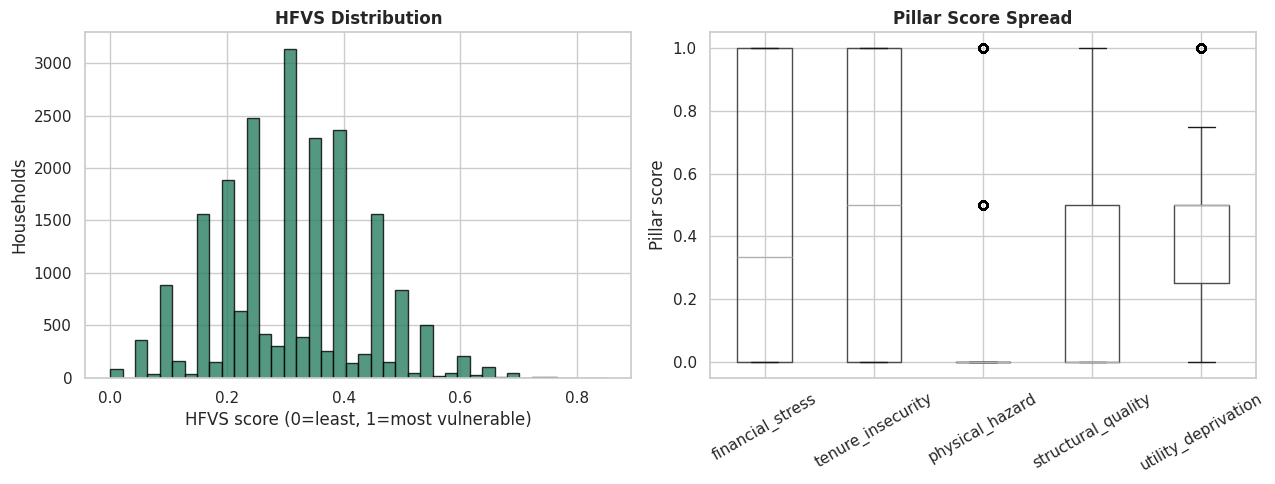

In [24]:
# 6.3  Quick visual check: HFVS should be roughly continuous and not a
# degenerate spike at one value, since that would indicate a pillar
# construction error rather than genuine vulnerability variation.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df_clean['hfvs_score'].dropna(), bins=40, color='#2A7F62', edgecolor='black', alpha=0.8)
axes[0].set_title('HFVS Distribution')
axes[0].set_xlabel('HFVS score (0=least, 1=most vulnerable)')
axes[0].set_ylabel('Households')

pillar_scores.boxplot(ax=axes[1], rot=30)
axes[1].set_title('Pillar Score Spread')
axes[1].set_ylabel('Pillar score')

fig.tight_layout()
fig.savefig(FIGS / 'v2_hfvs_construction_check.png', dpi=150, bbox_inches='tight')
plt.show()


In [25]:
# 7.1  Define the eligible candidate pool: every column except the
# target itself, its pillar components (which would trivially correlate
# since they are literally part of the target), identifiers, and raw
# survey weights (which are sampling-design artifacts, not predictors).
EXCLUDE_FROM_CANDIDATES = (
    ['hfvs_score'] + [c for c in df_clean.columns if c.startswith('pillar_')]
    + ['interview__key', 'serial', 'hhweight', 'inw', 'countycode']
)
candidate_cols = [c for c in df_clean.columns if c not in EXCLUDE_FROM_CANDIDATES]
print(f'Candidate pool for importance ranking: {len(candidate_cols)} columns '
      f'(out of {df_clean.shape[1]} total).')


Candidate pool for importance ranking: 528 columns (out of 538 total).


In [26]:
# 7.2  Split candidates into numeric-like and categorical-like by dtype
# and cardinality. A numeric column with very few distinct values
# (<=10) is treated as categorical/ordinal for testing purposes, since
# a Pearson correlation on a 3-level code is not meaningful.
numeric_candidates, categorical_candidates = [], []
for c in candidate_cols:
    s = df_clean[c]
    if pd.api.types.is_numeric_dtype(s) and s.nunique(dropna=True) > 10:
        numeric_candidates.append(c)
    else:
        categorical_candidates.append(c)

print(f'Numeric (continuous-like) candidates:    {len(numeric_candidates)}')
print(f'Categorical/ordinal/binary candidates:   {len(categorical_candidates)}')


Numeric (continuous-like) candidates:    76
Categorical/ordinal/binary candidates:   452


In [27]:
# 7.3  Numeric importance: Spearman correlation against HFVS (chosen
# over Pearson by default since many KHS monetary fields are skewed and
# HFVS itself is bounded; Spearman is monotonic-relationship robust).
numeric_importance = []
target = df_clean['hfvs_score']

for c in numeric_candidates:
    paired = pd.concat([df_clean[c], target], axis=1).dropna()
    if len(paired) < 30:
        continue
    rho, p = stats.spearmanr(paired[c], paired[target.name])
    numeric_importance.append({
        'variable': c,
        'n_obs': len(paired),
        'spearman_rho': rho,
        'abs_rho': abs(rho),
        'p_value': p,
        'significant_005': p < 0.05,
    })

numeric_importance_df = pd.DataFrame(numeric_importance).sort_values('abs_rho', ascending=False)
numeric_importance_df.to_csv(TABS / 'v2_numeric_importance_full.csv', index=False)
print(f'{len(numeric_importance_df)} numeric candidates tested.')
display(numeric_importance_df.head(25))


75 numeric candidates tested.


,variable,n_obs,spearman_rho,abs_rho,p_value,significant_005
35,k27,135,-0.2013,0.2013,0.0192,True
31,j12_1,20545,-0.0817,0.0817,0.0000,True
57,dw_floor_area_m2,20831,0.0780,0.0780,0.0000,True
68,mort_ltv_ratio,7770,-0.0776,0.0776,0.0000,True
24,g01g,21329,0.0766,0.0766,0.0000,True
28,g01k,21335,0.0760,0.0760,0.0000,True
67,wsvc_water_tariff,19113,-0.0663,0.0663,0.0000,True
66,wsvc_sewer_connections,20464,-0.0652,0.0652,0.0000,True
23,g01f,21338,0.0646,0.0646,0.0000,True
18,g01a,21340,0.0600,0.0600,0.0000,True


In [28]:
# 7.4  Categorical importance: Kruskal-Wallis H-test of HFVS across the
# levels of each categorical/ordinal/binary candidate. Eta-squared
# (effect size) is reported alongside the p-value, since with n~21,000
# almost everything will be "significant" and effect size is what
# actually distinguishes a meaningful driver from background noise.
categorical_importance = []

for c in categorical_candidates:
    paired = pd.concat([df_clean[c], target], axis=1).dropna()
    if len(paired) < 30:
        continue
    groups = [g[target.name].values for _, g in paired.groupby(c) if len(g) >= 5]
    if len(groups) < 2:
        continue
    h_stat, p = stats.kruskal(*groups)
    n = len(paired)
    k = len(groups)
    eta_sq = (h_stat - k + 1) / (n - k) if n > k else np.nan
    categorical_importance.append({
        'variable': c,
        'n_obs': n,
        'n_levels_tested': k,
        'h_statistic': h_stat,
        'eta_squared': eta_sq,
        'p_value': p,
        'significant_005': p < 0.05,
    })

categorical_importance_df = pd.DataFrame(categorical_importance).sort_values('eta_squared', ascending=False)
categorical_importance_df.to_csv(TABS / 'v2_categorical_importance_full.csv', index=False)
print(f'{len(categorical_importance_df)} categorical candidates tested.')
display(categorical_importance_df.head(25))


412 categorical candidates tested.


,variable,n_obs,n_levels_tested,h_statistic,eta_squared,p_value,significant_005
158,j10,21324,2,5465.5666,0.2563,0.0000,True
157,j09,21324,2,4908.4738,0.2302,0.0000,True
159,j11,21324,2,3921.3601,0.1839,0.0000,True
161,j13,21328,2,2564.4597,0.1202,0.0000,True
144,j05,21328,2,2311.0161,0.1083,0.0000,True
127,h01,21341,5,1969.6204,0.0921,0.0000,True
129,h03,21341,5,1943.2643,0.0909,0.0000,True
128,h02,21341,5,1856.7621,0.0868,0.0000,True
88,e06,21346,3,928.9671,0.0434,0.0000,True
181,j22__2,508,2,21.4993,0.0405,0.0000,True


In [29]:
# 7.5  Combine into one ranked importance table on a common scale.
# Spearman |rho| and eta-squared are not the same statistic, but both
# sit on a roughly comparable 0-1 "share of association" footing, which
# is enough to rank for narrowing purposes -- the actual modelling
# stage will use proper coefficients, not this ranking, for inference.
combined_rank = pd.concat([
    numeric_importance_df.rename(columns={'abs_rho': 'effect_size'})[['variable', 'effect_size', 'p_value', 'significant_005']].assign(var_type='numeric'),
    categorical_importance_df.rename(columns={'eta_squared': 'effect_size'})[['variable', 'effect_size', 'p_value', 'significant_005']].assign(var_type='categorical'),
], ignore_index=True).sort_values('effect_size', ascending=False)

combined_rank.to_csv(TABS / 'v2_combined_importance_ranking.csv', index=False)
print(f'Full ranked candidate pool: {len(combined_rank)} variables.')
display(combined_rank.head(40))


Full ranked candidate pool: 487 variables.


,variable,effect_size,p_value,significant_005,var_type
75,j10,0.2563,0.0000,True,categorical
76,j09,0.2302,0.0000,True,categorical
0,k27,0.2013,0.0192,True,numeric
77,j11,0.1839,0.0000,True,categorical
78,j13,0.1202,0.0000,True,categorical
79,j05,0.1083,0.0000,True,categorical
80,h01,0.0921,0.0000,True,categorical
81,h03,0.0909,0.0000,True,categorical
82,h02,0.0868,0.0000,True,categorical
1,j12_1,0.0817,0.0000,True,numeric


In [30]:
# 7.6  Progressive narrowing, shown as a funnel so the cut is visible
# rather than assumed. We narrow on a combination of statistical
# significance and a minimum effect-size floor, not on missingness
# alone -- a sparse-but-strong predictor (e.g. a hazard flag) should
# survive even if it has high missingness, provided that missingness is
# structural (section 3) and the signal is real.
funnel = []
funnel.append(('Full candidate pool', len(combined_rank)))

step1 = combined_rank[combined_rank['significant_005']]
funnel.append(('After: statistically significant (p<0.05)', len(step1)))

step2 = step1[step1['effect_size'] >= 0.02]
funnel.append(('After: effect size >= 0.02 (meaningful, not just detectable)', len(step2)))

step3 = step2.drop_duplicates(subset='variable')
funnel.append(('After: de-duplicated (some columns appear in both tests if borderline cardinality)', len(step3)))

funnel_df = pd.DataFrame(funnel, columns=['stage', 'n_variables'])
print(funnel_df.to_string(index=False))

MODEL_CANDIDATES = step3.sort_values('effect_size', ascending=False)
MODEL_CANDIDATES.to_csv(TABS / 'v2_model_candidate_shortlist.csv', index=False)
print()
print(f'Final shortlist carried into modelling: {len(MODEL_CANDIDATES)} variables.')
display(MODEL_CANDIDATES.head(50))


                                                                             stage  n_variables
                                                               Full candidate pool          487
                                         After: statistically significant (p<0.05)          333
                      After: effect size >= 0.02 (meaningful, not just detectable)           70
After: de-duplicated (some columns appear in both tests if borderline cardinality)           70

Final shortlist carried into modelling: 70 variables.


,variable,effect_size,p_value,significant_005,var_type
75,j10,0.2563,0.0000,True,categorical
76,j09,0.2302,0.0000,True,categorical
0,k27,0.2013,0.0192,True,numeric
77,j11,0.1839,0.0000,True,categorical
78,j13,0.1202,0.0000,True,categorical
79,j05,0.1083,0.0000,True,categorical
80,h01,0.0921,0.0000,True,categorical
81,h03,0.0909,0.0000,True,categorical
82,h02,0.0868,0.0000,True,categorical
1,j12_1,0.0817,0.0000,True,numeric


In [31]:
# 7.7  Final split of the shortlist into continuous and categorical
# lists, named to match the convention used in the modelling stage
# (MODEL_CONTINUOUS / MODEL_CATEGORICAL), so this notebook plugs
# directly into the next stage of the pipeline.
MODEL_CONTINUOUS = MODEL_CANDIDATES.loc[MODEL_CANDIDATES['var_type'] == 'numeric', 'variable'].tolist()
MODEL_CATEGORICAL = MODEL_CANDIDATES.loc[MODEL_CANDIDATES['var_type'] == 'categorical', 'variable'].tolist()

print(f'MODEL_CONTINUOUS:  {len(MODEL_CONTINUOUS)} variables')
print(f'MODEL_CATEGORICAL: {len(MODEL_CATEGORICAL)} variables')
print()
print('Continuous:', MODEL_CONTINUOUS)
print()
print('Categorical:', MODEL_CATEGORICAL)


MODEL_CONTINUOUS:  51 variables
MODEL_CATEGORICAL: 19 variables

Continuous: ['k27', 'j12_1', 'dw_floor_area_m2', 'mort_ltv_ratio', 'g01g', 'g01k', 'wsvc_water_tariff', 'wsvc_sewer_connections', 'g01f', 'g01a', 'c10', 'c10_3', 'l20_c', 'hh_size', 'a12', 'fin_portfolio', 'nema_eia_approvals', 'n_female', 'wsvc_water_connections', 'dependency_ratio', 'l20_b', 'dw_wall_material', 'g01d', 'l08', 'c04', 'loan_n_providers', 'g01e', 'g01c', 'max_edu_isced', 'dw_roof_material', 'g01b', 'cty_housing_stock', 'nema_eia_applications', 'c06', 'loan_avg_size', 'l07', 'g01i', 'l19', 'c12_1_1', 'nema_processing_days', 'fin_avg_tenure_months', 'a01', 'c10_2', 'c02_4', 'g02_1', 'l28', 'e05', 'c11_2_1', 'c01_4', 'selectedage', 'l15']

Categorical: ['j10', 'j09', 'j11', 'j13', 'j05', 'h01', 'h03', 'h02', 'e06', 'j22__2', 'e07', 'mort_interest_rate', 'h07', 'c05', 'mort_avg_term_years', 'ctymin_ut', 'd20__9', 'c01_3', 'h09']


In [32]:
# 7.8  Save the cleaned, importance-ranked working frame so the next
# notebook stage (parametric + nonparametric testing) can load it
# directly without repeating the cleaning and ranking work above.
model_df_cols = ['hfvs_score'] + [c for c in df_clean.columns if c.startswith('pillar_')] + MODEL_CONTINUOUS + MODEL_CATEGORICAL
model_df_cols = list(dict.fromkeys(model_df_cols))  # de-dupe, preserve order
model_df = df_clean[model_df_cols].copy()

model_df.to_parquet(PQ / 'model_df_v2.parquet')
print(f'Saved model_df_v2.parquet: {model_df.shape[0]:,} rows x {model_df.shape[1]} columns')
print(f'Location: {PQ / "model_df_v2.parquet"}')


Saved model_df_v2.parquet: 21,347 rows x 76 columns
Location: /content/drive/MyDrive/KHS_Dissertation/data/parquet/model_df_v2.parquet


In [33]:
# 8.1  Stage summary: what this notebook established and what carries
# forward into the next stage (parametric + nonparametric testing).
print('=== STAGE 1 SUMMARY ===')
print(f'Source frame:        {DATA_PATH.name} ({df.shape[0]:,} rows x {df.shape[1]} columns)')
print(f'Registry coverage:   {n_registered} of {df.shape[1]} columns documented')
print(f'Sentinel pairs found: {len(sentinel_df)} (column, code) combinations neutralised')
print(f'Structural-missing columns recoded: {len(structural_missing_cols)}')
print(f'lp_* mixed-type columns fixed:      {len(lp_cols)}')
print(f'HFVS households with complete pillars: {pillar_scores.notna().all(axis=1).sum():,}')
print(f'Candidates tested for importance:   {len(combined_rank)}')
print(f'Final modelling shortlist:          {len(MODEL_CANDIDATES)} '
      f'({len(MODEL_CONTINUOUS)} continuous, {len(MODEL_CATEGORICAL)} categorical)')
print()
print('Saved outputs:')
for f in sorted(TABS.glob('v2_*.csv')):
    print(f'  {f.name}')
print(f'  {PQ / "model_df_v2.parquet"}')
print()
print('Next stage: EDA, normality testing, Part C parametric methods, '
      'Part D nonparametric methods, using model_df_v2.parquet as the input.')


=== STAGE 1 SUMMARY ===
Source frame:        master_frame.parquet (21,347 rows x 443 columns)
Registry coverage:   97 of 443 columns documented
Sentinel pairs found: 157 (column, code) combinations neutralised
Structural-missing columns recoded: 84
lp_* mixed-type columns fixed:      0
HFVS households with complete pillars: 21,347
Candidates tested for importance:   487
Final modelling shortlist:          70 (51 continuous, 19 categorical)

Saved outputs:
  v2_categorical_importance_full.csv
  v2_combined_importance_ranking.csv
  v2_consistency_check_report.csv
  v2_model_candidate_shortlist.csv
  v2_module_conditional_missingness.csv
  v2_numeric_importance_full.csv
  v2_sentinel_code_audit.csv
  /content/drive/MyDrive/KHS_Dissertation/data/parquet/model_df_v2.parquet

Next stage: EDA, normality testing, Part C parametric methods, Part D nonparametric methods, using model_df_v2.parquet as the input.
